# ASCII art POC

`real image -> ASCII art -> local LLM (Ollama) -> ASCII art -> rendered image`

Runs fully offline against a local Ollama server. See `PLAN.md` for the plan, `LOG.md` for decisions.

## 0. Setup

In [1]:
import time, json, base64, requests
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

OLLAMA = "http://localhost:11434"
MODELS = ["llama3.2:3b", "qwen2.5:7b", "gemma2:9b"]   # edit to taste
VISION_MODEL = "llava"                                 # optional baseline
CHARS  = " .:-=+*#%@"                                  # light -> dark
WIDTH  = 80                                            # ASCII columns

Path("images").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)

installed = [m["name"] for m in requests.get(f"{OLLAMA}/api/tags").json()["models"]]
MODELS = [m for m in MODELS if m in installed]
print("installed:", installed)
print("testing:  ", MODELS)

installed: ['llama3.2:3b', 'nomic-embed-text:latest']
testing:   ['llama3.2:3b']


Sample images (only created if `images/` is empty), so the notebook runs without any downloads.

In [2]:
if not any(Path("images").iterdir()):
    img = Image.new("L", (400, 400), 255); d = ImageDraw.Draw(img)
    d.ellipse((80, 80, 320, 320), fill=0)
    img.save("images/circle.png")

    img = Image.new("L", (400, 400), 255); d = ImageDraw.Draw(img)
    d.polygon([(50, 350), (200, 50), (350, 350)], fill=0)
    img.save("images/triangle.png")

    img = Image.new("L", (400, 400), 255); d = ImageDraw.Draw(img)
    d.ellipse((50, 50, 350, 350), fill=200, outline=0, width=8)
    d.ellipse((120, 130, 170, 180), fill=0); d.ellipse((230, 130, 280, 180), fill=0)
    d.arc((110, 160, 290, 300), 20, 160, fill=0, width=10)
    img.save("images/smiley.png")

    x = np.linspace(0, 255, 400).astype(np.uint8)
    Image.fromarray(np.tile(x, (400, 1))).save("images/gradient.png")
sorted(p.name for p in Path("images").iterdir())

['circle.png', 'gradient.png', 'smiley.png', 'triangle.png']

## 1. Image -> ASCII

In [3]:
def image_to_ascii(path, width=WIDTH):
    img = Image.open(path).convert("L")
    h = max(1, int(img.height / img.width * width * 0.5))   # chars are ~2x taller than wide
    px = np.array(img.resize((width, h))) / 255
    idx = ((1 - px) * (len(CHARS) - 1)).round().astype(int)
    return "\n".join("".join(CHARS[i] for i in row) for row in idx)

print(image_to_ascii("images/smiley.png"))

                                                                                
                                                                                
                                                                                
                                                                                
                                     ......                                     
                             .:=+**##########**+=-.                             
                         :=*##**+=--::::::::--==+*##*=:                         
                      :+##*=-::::::::::::::::::::::-=*##+:                      
                    =##*-::::::::::::::::::::::::::::::-+##=.                   
                  =##=::::::::::::::::::::::::::::::::::::-*%+.                 
                -##=::::::::::::::::::::::::::::::::::::::::-#%=                
              .+%+::::::::::::::::::::::::::::::::::::::::::::=%#.              
             .#%-:::::::::::

## 2. Call Ollama

In [4]:
def ask(model, prompt, images=None):
    body = {"model": model, "prompt": prompt, "stream": False,
            "options": {"temperature": 0, "num_ctx": 8192, "num_predict": 4096}}
    if images:
        body["images"] = images
    t0 = time.time()
    r = requests.post(f"{OLLAMA}/api/generate", json=body, timeout=900).json()
    # a broken generation can come back with done=False and no stats: record it, don't crash
    ns = lambda k: r.get(k, 0) / 1e9
    return r.get("response", ""), {
        "done":       r.get("done", False),
        "total_s":    ns("total_duration") or time.time() - t0,
        "load_s":     ns("load_duration"),
        "in_tokens":  r.get("prompt_eval_count", 0),
        "out_tokens": r.get("eval_count", 0),
        "tok_per_s":  r.get("eval_count", 0) / ns("eval_duration") if r.get("eval_duration") else 0.0,
    }

for m in MODELS:   # warm-up so load time doesn't skew results
    print(m, ask(m, "Say hi.")[1])

llama3.2:3b {'done': True, 'total_s': 0.4041355, 'load_s': 0.194908583, 'in_tokens': 28, 'out_tokens': 10, 'tok_per_s': 59.53018775821219}


## 3. Tasks

In [5]:
TASKS = {
    "describe": "Describe what this ASCII art shows in one sentence.",
    "flip":     "Mirror this ASCII art horizontally. Output only the ASCII art, same size.",
    "invert":   f"Invert brightness using this ramp (light to dark): '{CHARS}'. Output only the ASCII art, same size.",
    "edit":     "Add a small sun in the top-right corner. Output only the ASCII art, same size.",
}

def make_prompt(instruction, art):
    return f"{instruction}\n\n```\n{art}\n```"

## 4. Validate output

In [6]:
def clean(text):
    lines = text.strip("\n").splitlines()
    return "\n".join(l for l in lines if not l.strip().startswith("```"))

def grid_ok(inp, out):
    a, b = inp.splitlines(), out.splitlines()
    return len(a) == len(b) and all(len(x) == len(y) for x, y in zip(a, b))

def expected(task, art):
    if task == "flip":
        return "\n".join(l[::-1] for l in art.splitlines())
    if task == "invert":
        return art.translate(str.maketrans(CHARS, CHARS[::-1]))
    return None

def char_accuracy(exp, out):
    a, b = exp.splitlines(), out.splitlines()
    hits = sum(x == y for la, lb in zip(a, b) for x, y in zip(la, lb))
    return hits / max(1, sum(map(len, a)))

## 5. ASCII -> image

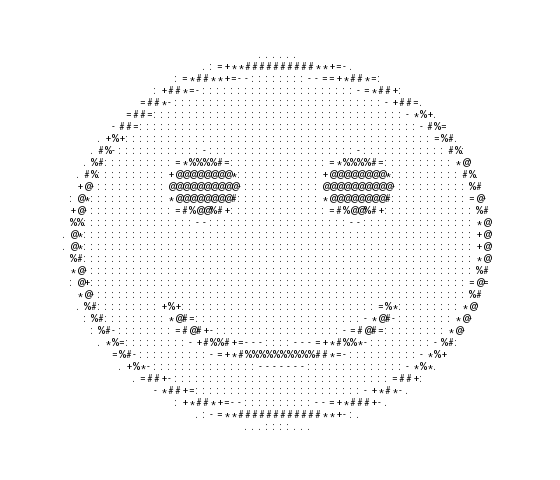

In [7]:
FONT = ImageFont.load_default()
CW, CH = 7, 12   # cell size; each char drawn in its own cell, so font needn't be monospace

def ascii_to_image(text, path=None):
    lines = text.splitlines() or [""]
    img = Image.new("L", (max(1, max(map(len, lines))) * CW, len(lines) * CH), 255)
    d = ImageDraw.Draw(img)
    for y, line in enumerate(lines):
        for x, c in enumerate(line):
            if c != " ":
                d.text((x * CW, y * CH), c, fill=0, font=FONT)
    if path:
        img.save(path)
    return img

ascii_to_image(image_to_ascii("images/smiley.png"))

## 6. Benchmark

In [8]:
rows = []
for img in sorted(Path("images").glob("*.png")):
    art = image_to_ascii(img)
    ascii_to_image(art, f"results/{img.stem}_input.png")
    for model in MODELS:
        for task, instr in TASKS.items():
            out, stats = ask(model, make_prompt(instr, art))
            row = {"image": img.name, "model": model, "task": task, **stats}
            if task == "describe":
                row["answer"] = out.strip()
            else:
                out = clean(out)
                row["grid_ok"] = grid_ok(art, out)
                exp = expected(task, art)
                row["char_acc"] = char_accuracy(exp, out) if exp else None
                ascii_to_image(out, f"results/{img.stem}_{model.replace(':', '-')}_{task}.png")
            rows.append(row)
            print(f"{img.name:14} {model:14} {task:9} {stats['total_s']:6.1f}s {stats['tok_per_s']:5.1f} tok/s")

df = pd.DataFrame(rows)
df.to_csv("results/benchmarks.csv", index=False)

circle.png     llama3.2:3b    describe     0.9s  53.9 tok/s


circle.png     llama3.2:3b    flip         7.6s  53.4 tok/s


circle.png     llama3.2:3b    invert       7.4s  53.3 tok/s


circle.png     llama3.2:3b    edit         7.6s  53.5 tok/s


gradient.png   llama3.2:3b    describe     0.6s  55.2 tok/s


...

smiley.png     llama3.2:3b    edit         9.8s  52.9 tok/s


triangle.png   llama3.2:3b    describe     1.5s  55.4 tok/s


triangle.png   llama3.2:3b    flip        83.4s  49.7 tok/s


triangle.png   llama3.2:3b    invert       6.8s  53.5 tok/s


triangle.png   llama3.2:3b    edit        83.4s  49.7 tok/s


## 7. Results

In [9]:
df.groupby(["model", "task"])[["done", "total_s", "in_tokens", "out_tokens", "tok_per_s", "grid_ok", "char_acc"]].mean()

done    total_s  in_tokens  out_tokens  tok_per_s  \
model       task                                                          
llama3.2:3b describe  1.00   1.175855     479.25       29.25  54.963480   
            edit      1.00  46.313212     488.25     2262.75  51.333607   
            flip      1.00  46.212151     484.25     2257.75  51.327161   
            invert    0.75   6.064974     344.00      279.75  39.956243   

                     grid_ok  char_acc  
model       task                        
llama3.2:3b describe     NaN       NaN  
            edit        0.25       NaN  
            flip         0.5      0.48  
            invert       0.0      0.04

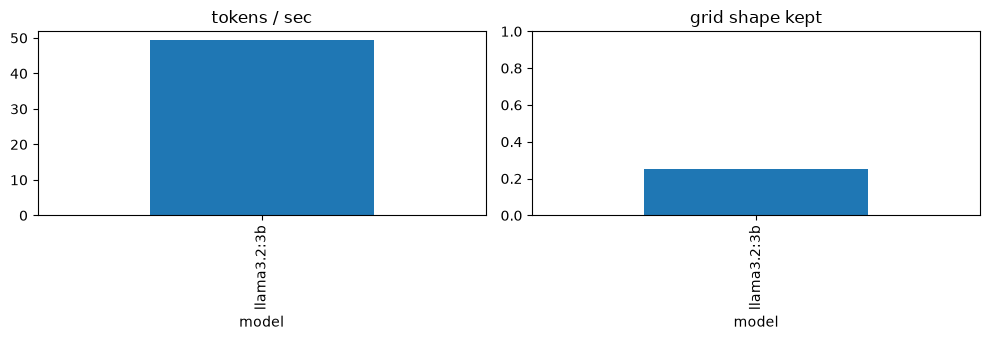

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
df.groupby("model")["tok_per_s"].mean().plot.bar(ax=ax[0], title="tokens / sec")
df[df.task != "describe"].groupby("model")["grid_ok"].mean().plot.bar(ax=ax[1], title="grid shape kept", ylim=(0, 1))
plt.tight_layout(); plt.show()

In [11]:
df[df.task == "describe"][["image", "model", "answer"]]

,image,model,answer
0,circle.png,llama3.2:3b,"This ASCII art depicts a stylized, futuristic ..."
4,gradient.png,llama3.2:3b,"This ASCII art depicts a large, seemingly endl..."
8,smiley.png,llama3.2:3b,"This ASCII art depicts a stylized, abstract re..."
12,triangle.png,llama3.2:3b,This ASCII art depicts a staircase with 10 ste...


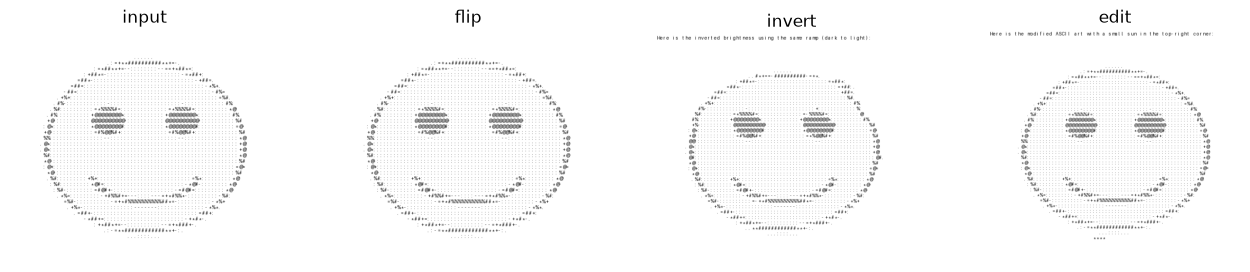

In [12]:
def show(image, model):
    stem, m = Path(image).stem, model.replace(":", "-")
    paths = [f"results/{stem}_input.png"] + [f"results/{stem}_{m}_{t}.png" for t in TASKS if t != "describe"]
    fig, ax = plt.subplots(1, len(paths), figsize=(4 * len(paths), 3))
    for a, p, t in zip(ax, paths, ["input"] + [t for t in TASKS if t != "describe"]):
        a.imshow(Image.open(p), cmap="gray"); a.set_title(t); a.axis("off")
    plt.show()

for model in MODELS:
    show("smiley.png", model)

### Baseline: vision model on the real image (optional)\n\nSkipped unless `VISION_MODEL` is pulled. Compares tokens/time for pixels vs. ASCII on the `describe` task.

In [13]:
vision = next((m for m in installed if m.split(":")[0] == VISION_MODEL), None)
if vision:
    ask(vision, "Say hi.")
    base = []
    for img in sorted(Path("images").glob("*.png")):
        b64 = base64.b64encode(img.read_bytes()).decode()
        _, s = ask(vision, "Describe this image in one sentence.", images=[b64])
        base.append({"image": img.name, "input": "pixels", **s})
        _, s = ask(vision, make_prompt(TASKS["describe"], image_to_ascii(img)))
        base.append({"image": img.name, "input": "ascii", **s})
    display(pd.DataFrame(base).groupby("input")[["total_s", "in_tokens", "out_tokens"]].mean())
else:
    print(f"no {VISION_MODEL} model installed; skipping baseline")

no llava model installed; skipping baseline
